# 02 — Wavelet decomposition

Each series is split into trend and seasonal components by multiresolution analysis
with a discrete Meyer wavelet at its native cadence, then aggregated to monthly. The
trend/seasonal boundary is set at one year.

Input: `data/raw/` · Output: `data/processed/orchard_decomposed.csv`

In [1]:
import warnings

import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Expected at these levels and explained under "Boundary handling" below; silenced
# so the diagnostic output stays readable.
warnings.filterwarnings("ignore", message="Level value of .* is too high")

master = pd.read_csv("../data/raw/orchard_monthly.csv",
                     index_col="date", parse_dates=True)

ndvi16 = (pd.read_csv("../data/raw/orchard_ndvi_16day.csv", parse_dates=["date"])
            .set_index("date")["NDVI"])
lst8 = (pd.read_csv("../data/raw/orchard_lst_8day.csv", parse_dates=["date"])
          .set_index("date")["LST"])

SPEI_COLS = ["SPEI_1", "SPEI_3", "SPEI_6", "SPEI_12", "SPEI_24", "SPEI_48"]
ALL_SERIES = ["NDVI", "LST"] + SPEI_COLS

print(f"monthly {master.shape}   16-day NDVI {len(ndvi16)}   8-day LST {len(lst8)}")
print(f"NDVI composites masked as cloud: {ndvi16.isna().sum()} of {len(ndvi16)} -> interpolated")
print(f"LST composites withheld by MODIS: {lst8.isna().sum()} of {len(lst8)} -> interpolated")
ndvi16 = ndvi16.interpolate()
lst8 = lst8.interpolate()

monthly (298, 10)   16-day NDVI 571   8-day LST 1141
NDVI composites masked as cloud: 8 of 571 -> interpolated
LST composites withheld by MODIS: 8 of 1141 -> interpolated


## Levels

The level is chosen so the cut falls nearest one year, with semi-period
`p = 2^J · Δt / (2 · v_c)`. This gives 5 for 16-day NDVI, 6 for 8-day LST and 4 for
monthly SPEI, the same as Bounouh et al. (2024), Table 3.

In [2]:
WAVELET = "dmey"
V_C = pywt.central_frequency(WAVELET)
CADENCE = {"NDVI": 16.0, "LST": 8.0, "SPEI": 365.25 / 12}
TARGET_DAYS = 365.25


def semi_period(level, dt):
    return 2 ** level * dt / (2 * V_C)


LEVELS = {k: min(range(2, 9), key=lambda j: abs(semi_period(j, dt) - TARGET_DAYS))
          for k, dt in CADENCE.items()}

print(f"{WAVELET}: centre frequency {V_C:.4f}, filter length "
      f"{pywt.Wavelet(WAVELET).dec_len}\n")
print(f"{'index':6s} {'dt (d)':>7s} {'level':>6s} {'scale':>6s} "
      f"{'semi-period':>12s}   neighbours")
for k, dt in CADENCE.items():
    j = LEVELS[k]
    print(f"{k:6s} {dt:7.2f} {j:6d} {2**j:6d} {semi_period(j, dt):10.0f} d   "
          f"level {j-1} -> {semi_period(j-1, dt):.0f} d, "
          f"level {j+1} -> {semi_period(j+1, dt):.0f} d")

assert LEVELS == {"NDVI": 5, "LST": 6, "SPEI": 4}, LEVELS
print("\nderived levels match Bounouh et al. (2024) Table 3")

dmey: centre frequency 0.6721, filter length 62

index   dt (d)  level  scale  semi-period   neighbours
NDVI     16.00      5     32        381 d   level 4 -> 190 d, level 6 -> 762 d
LST       8.00      6     64        381 d   level 5 -> 190 d, level 7 -> 762 d
SPEI     30.44      4     16        362 d   level 3 -> 181 d, level 5 -> 725 d

derived levels match Bounouh et al. (2024) Table 3


## Decomposition

Series mirrored at both ends before decomposing (Ben Abbes et al., 2018). Trend is
`A_J`; seasonal is the residual, so trend + seasonal is exact. Cloud-masked NDVI and
missing LST composites are interpolated first.

In [3]:
def decompose(series, level, pad_frac=0.5):
    """MRA at the series' own cadence, with the series mirrored at both ends."""
    x = series.to_numpy(float)
    n = len(x)
    p = int(pad_frac * n)
    xp = np.concatenate([x[:p][::-1], x, x[-p:][::-1]])

    comps = [c[p:p + n] for c in
             pywt.mra(xp, WAVELET, level=level, transform="dwt", mode="symmetric")]

    trend = pd.Series(comps[0], index=series.index)
    finest = pd.Series(comps[-1], index=series.index)
    return trend, series - trend, finest


decomp = master.copy()
finest_share = {}

for name, series in [("NDVI", ndvi16), ("LST", lst8)]:          # native cadence
    trend, seasonal, d1 = decompose(series, LEVELS[name])
    decomp[name] = series.resample("MS").mean()   # gap-filled, so T + S = series
    decomp[f"{name}_T"] = trend.resample("MS").mean()
    decomp[f"{name}_S"] = seasonal.resample("MS").mean()
    finest_share[name] = d1.std() / series.std()

for col in SPEI_COLS:                                           # already monthly
    trend, seasonal, d1 = decompose(master[col], LEVELS["SPEI"])
    decomp[f"{col}_T"], decomp[f"{col}_S"] = trend, seasonal
    finest_share[col] = d1.std() / master[col].std()

for col in ALL_SERIES:
    src = {"NDVI": ndvi16, "LST": lst8}.get(col, master[col])
    lvl = LEVELS[col] if col in LEVELS else LEVELS["SPEI"]
    print(f"{col:8s} n={len(src):5d}  level {lvl}  "
          f"trend sd {decomp[f'{col}_T'].std():7.4f}  "
          f"seasonal sd {decomp[f'{col}_S'].std():8.4f}  "
          f"D1 {finest_share[col]:5.1%} of series sd")

print(f"\n{decomp.shape}")

NDVI     n=  571  level 5  trend sd  0.0281  seasonal sd   0.1654  D1  9.9% of series sd
LST      n= 1141  level 6  trend sd  1.0128  seasonal sd  11.2318  D1 13.8% of series sd
SPEI_1   n=  298  level 4  trend sd  0.3111  seasonal sd   1.0007  D1 65.3% of series sd
SPEI_3   n=  298  level 4  trend sd  0.5231  seasonal sd   0.9062  D1 31.2% of series sd
SPEI_6   n=  298  level 4  trend sd  0.7361  seasonal sd   0.7548  D1 26.6% of series sd
SPEI_12  n=  298  level 4  trend sd  0.9224  seasonal sd   0.5980  D1 14.9% of series sd
SPEI_24  n=  298  level 4  trend sd  1.0629  seasonal sd   0.2707  D1 10.0% of series sd
SPEI_48  n=  298  level 4  trend sd  1.0178  seasonal sd   0.2349  D1  7.3% of series sd

(298, 26)


## Verification

In [4]:
print("exact reconstruction, max |T + S - series|:")
for col in ALL_SERIES:
    err = (decomp[f"{col}_T"] + decomp[f"{col}_S"] - decomp[col]).abs().max()
    print(f"  {col:8s} {err:.2e}")

print(f"\n{'series':8s} {'trend':>8s} {'seasonal':>9s} {'D1 share':>9s}")
for col in ALL_SERIES:
    vt, vs = decomp[f"{col}_T"].var(), decomp[f"{col}_S"].var()
    print(f"{col:8s} {vt / (vt + vs):7.1%} {vs / (vt + vs):8.1%} "
          f"{finest_share[col]:8.1%}")

print("\nSPEI climatology by calendar month "
      "(flat if SPEI is standardised per month, as documented):")
print(master.groupby(master.index.month)[SPEI_COLS].mean().round(2).to_string())

exact reconstruction, max |T + S - series|:
  NDVI     1.11e-16
  LST      7.11e-15
  SPEI_1   2.22e-16
  SPEI_3   2.22e-16
  SPEI_6   2.22e-16
  SPEI_12  5.55e-17
  SPEI_24  5.55e-17
  SPEI_48  5.55e-17

series      trend  seasonal  D1 share
NDVI        2.8%    97.2%     9.9%
LST         0.8%    99.2%    13.8%
SPEI_1      8.8%    91.2%    65.3%
SPEI_3     25.0%    75.0%    31.2%
SPEI_6     48.7%    51.3%    26.6%
SPEI_12    70.4%    29.6%    14.9%
SPEI_24    93.9%     6.1%    10.0%
SPEI_48    94.9%     5.1%     7.3%

SPEI climatology by calendar month (flat if SPEI is standardised per month, as documented):
      SPEI_1  SPEI_3  SPEI_6  SPEI_12  SPEI_24  SPEI_48
date                                                   
1      -0.23   -0.21   -0.25    -0.46    -0.65    -0.84
2      -0.19   -0.26   -0.26    -0.42    -0.62    -0.79
3      -0.09   -0.29   -0.29    -0.48    -0.63    -0.76
4      -0.22   -0.26   -0.33    -0.48    -0.63    -0.78
5      -0.18   -0.21   -0.40    -0.49    -0.63  

## Decomposed series

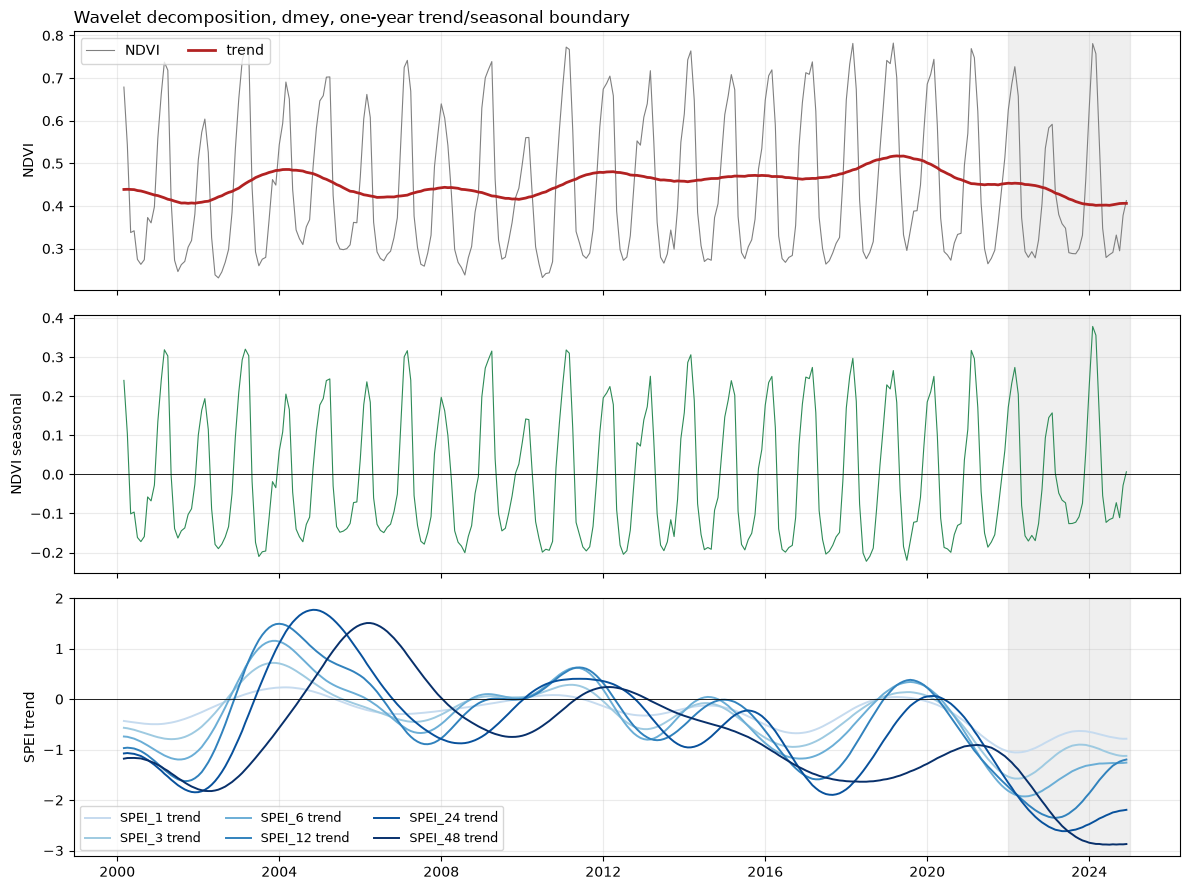

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
d = decomp.index

axes[0].plot(d, decomp["NDVI"], color="grey", lw=0.8, label="NDVI")
axes[0].plot(d, decomp["NDVI_T"], color="firebrick", lw=2, label="trend")
axes[0].set_ylabel("NDVI")
axes[0].legend(loc="upper left", ncol=2)

axes[1].plot(d, decomp["NDVI_S"], color="seagreen", lw=0.8)
axes[1].axhline(0, color="black", lw=0.6)
axes[1].set_ylabel("NDVI seasonal")

for col, shade in zip(SPEI_COLS, ["#c6dbef", "#9ecae1", "#6baed6", "#3182bd",
                                  "#08519c", "#08306b"]):
    axes[2].plot(d, decomp[f"{col}_T"], lw=1.4, color=shade, label=f"{col} trend")
axes[2].axhline(0, color="black", lw=0.6)
axes[2].set_ylabel("SPEI trend")
axes[2].legend(loc="lower left", ncol=3, fontsize=9)

for ax in axes:
    ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2024-12-31"),
               color="grey", alpha=0.12, zorder=0)
    ax.grid(alpha=0.25)

axes[0].set_title("Wavelet decomposition, dmey, one-year trend/seasonal boundary",
                  loc="left")
fig.tight_layout()
fig.savefig("../figures/02_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

## Look-ahead

The wavelet filter is two-sided, so the trend at month *t* uses later months. A
causal trend, recomputed with data up to each point only, measures the effect.

In [6]:
def causal_trend(series, level, burn_in):
    """Trend at each t recomputed from observations up to t only."""
    out = np.full(len(series), np.nan)
    for t in range(burn_in, len(series) + 1):
        trend, _, _ = decompose(series.iloc[:t], level)
        out[t - 1] = trend.iloc[-1]
    return pd.Series(out, index=series.index)


BURN_IN_YEARS = 8
PER_YEAR = {"NDVI": 365.25 / 16, "LST": 365.25 / 8, "SPEI": 12}

for name, series in [("NDVI", ndvi16), ("LST", lst8)]:
    burn = int(BURN_IN_YEARS * PER_YEAR[name])
    decomp[f"{name}_Tc"] = (causal_trend(series, LEVELS[name], burn)
                            .resample("MS").mean())

for col in SPEI_COLS:
    decomp[f"{col}_Tc"] = causal_trend(master[col], LEVELS["SPEI"],
                                       int(BURN_IN_YEARS * PER_YEAR["SPEI"]))

print(f"{'series':9s} {'lag-1 (2-sided)':>16s} {'lag-1 (causal)':>15s} "
      f"{'persist R2 2-sided':>19s} {'persist R2 causal':>18s} {'corr':>7s}")
for col in ALL_SERIES:
    a, b = decomp[f"{col}_T"], decomp[f"{col}_Tc"]
    m = b.notna()
    a, b = a[m], b[m]
    print(f"{col:9s} {a.autocorr(1):16.4f} {b.autocorr(1):15.4f} "
          f"{r2_score(a[1:], a[:-1]):19.4f} {r2_score(b[1:], b[:-1]):18.4f} "
          f"{a.corr(b):7.3f}")

series     lag-1 (2-sided)  lag-1 (causal)  persist R2 2-sided  persist R2 causal    corr
NDVI                0.9973          0.9081              0.9946             0.8166   0.498
LST                 0.9883          0.8775              0.9767             0.7541   0.167
SPEI_1              0.9974          0.9395              0.9947             0.8795   0.784
SPEI_3              0.9971          0.9743              0.9942             0.9486   0.806
SPEI_6              0.9970          0.9859              0.9940             0.9718   0.829
SPEI_12             0.9971          0.9903              0.9943             0.9806   0.867
SPEI_24             0.9979          0.9961              0.9956             0.9921   0.970
SPEI_48             0.9992          0.9974              0.9980             0.9944   0.974


The causal wavelet trend oscillates annually, a boundary artefact present under every
padding rule. A trailing 12-month mean is used as a causal reference instead, since it
cannot leak the annual cycle.

In [7]:
def causal_last(x, level, right_pad):
    """Trend value at the final point of x, under a given right-edge rule."""
    n = len(x)
    p = int(0.5 * n)
    right = {"mirror": x[-p:][::-1],
             "constant": np.full(p, x[-1]),
             "none": np.empty(0)}[right_pad]
    xp = np.concatenate([x[:p][::-1], x, right])
    return pywt.mra(xp, WAVELET, level=level,
                    transform="dwt", mode="symmetric")[0][p + n - 1]


x = ndvi16.to_numpy(float)
burn = int(BURN_IN_YEARS * PER_YEAR["NDVI"])

variants = {"wavelet, two-sided": decomp["NDVI_T"]}
for rule in ("mirror", "constant", "none"):
    out = np.full(len(x), np.nan)
    for t in range(burn, len(x) + 1):
        out[t - 1] = causal_last(x[:t], LEVELS["NDVI"], rule)
    variants[f"causal wavelet, {rule} pad"] = (
        pd.Series(out, index=ndvi16.index).resample("MS").mean())

for w in (12, 24):
    variants[f"trailing {w}-month mean"] = decomp["NDVI"].rolling(w).mean()

print(f"{'estimator':30s} {'sd':>7s} {'annual leak':>12s} {'lag-1':>7s} "
      f"{'persist R2':>11s} {'corr w/ 2-sided':>16s}")
for name, c in variants.items():
    k = c.notna()
    amp = (c[k].groupby(c[k].index.month).mean()
                .pipe(lambda v: v.max() - v.min()))
    print(f"{name:30s} {c.std():7.4f} {amp:12.4f} {c[k].autocorr(1):7.4f} "
          f"{r2_score(c[k][1:], c[k][:-1]):11.4f} "
          f"{decomp['NDVI_T'][k].corr(c[k]):16.3f}")

estimator                           sd  annual leak   lag-1  persist R2  corr w/ 2-sided
wavelet, two-sided              0.0281       0.0018  0.9968      0.9936            1.000
causal wavelet, mirror pad      0.0517       0.1099  0.9081      0.8166            0.498
causal wavelet, constant pad    0.0914       0.2274  0.8350      0.6692            0.271
causal wavelet, none pad        0.0479       0.1011  0.9002      0.8009            0.463
trailing 12-month mean          0.0327       0.0008  0.9742      0.9483            0.707
trailing 24-month mean          0.0243       0.0023  0.9916      0.9832            0.677


`_Tc`: causal wavelet trend. `_Tm`: trailing 12-month mean. Neither is a predictor.

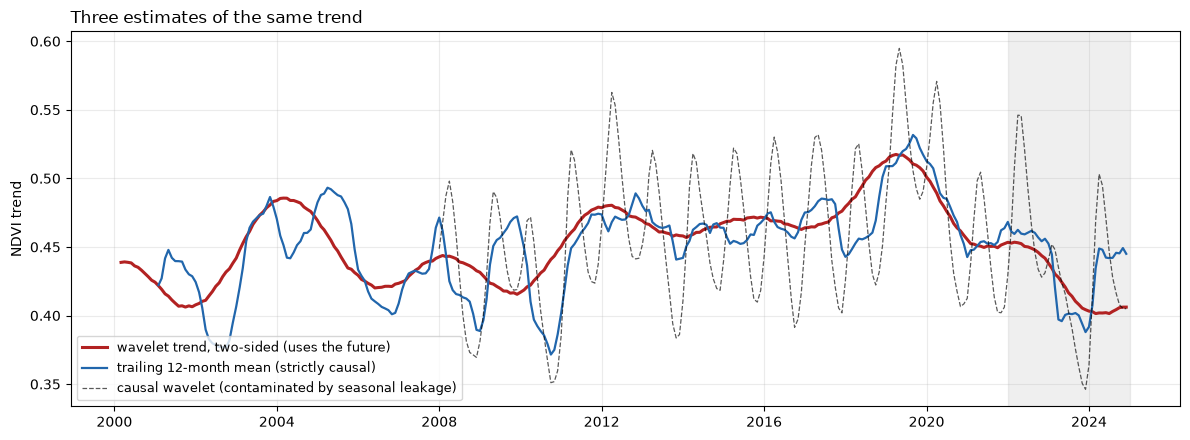

In [8]:
for col in ALL_SERIES:
    decomp[f"{col}_Tm"] = decomp[col].rolling(12).mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(decomp.index, decomp["NDVI_T"], color="firebrick", lw=2.2,
        label="wavelet trend, two-sided (uses the future)")
ax.plot(decomp.index, decomp["NDVI_Tm"], color="#2166ac", lw=1.6,
        label="trailing 12-month mean (strictly causal)")
ax.plot(decomp.index, decomp["NDVI_Tc"], color="black", lw=0.9, ls="--",
        alpha=0.65, label="causal wavelet (contaminated by seasonal leakage)")
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2024-12-31"),
           color="grey", alpha=0.12, zorder=0)
ax.set_ylabel("NDVI trend")
ax.grid(alpha=0.25)
ax.legend(loc="lower left", fontsize=9)
ax.set_title("Three estimates of the same trend", loc="left")
fig.tight_layout()
fig.savefig("../figures/02_causal_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## Saving

In [9]:
decomp.to_csv("../data/processed/orchard_decomposed.csv")

print(decomp.shape)
print(f"\nnulls by suffix:")
for suffix in ("", "_T", "_S", "_Tc", "_Tm"):
    cols = [f"{c}{suffix}" for c in ALL_SERIES]
    print(f"  {suffix or '(series)':10s} {decomp[cols].isna().sum().sum():4d}  "
          f"first valid {decomp[cols].dropna().index[0].date()}")

(298, 42)

nulls by suffix:
  (series)      0  first valid 2000-03-01
  _T            0  first valid 2000-03-01
  _S            0  first valid 2000-03-01
  _Tc         759  first valid 2008-02-01
  _Tm          88  first valid 2001-02-01
